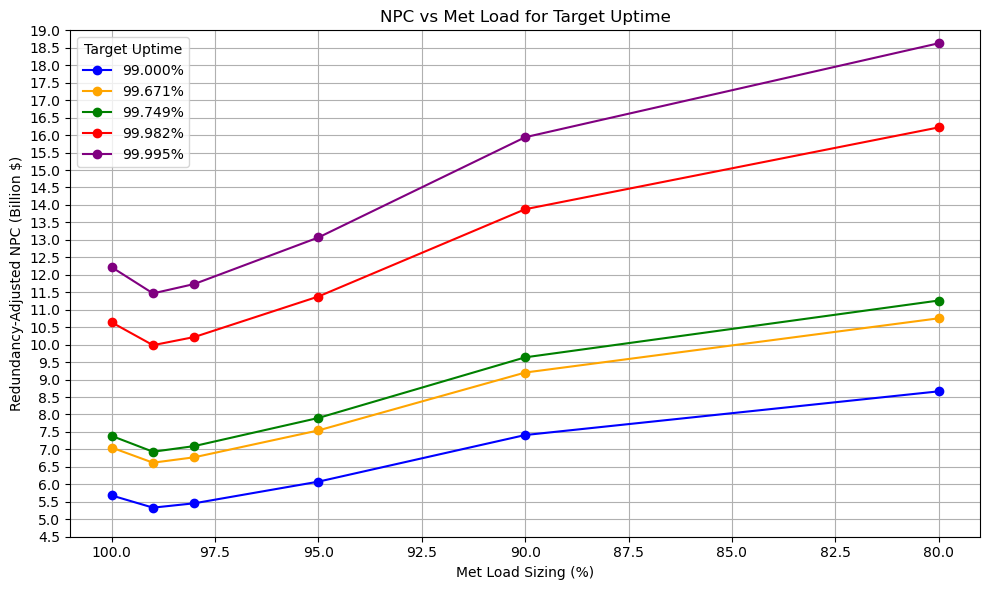


=== Reliability Target: 99.000% ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.000%),Max Total NPC ($),Redundancy-Adjusted NPC ($)
0,80,73.497661,72.523,3.56484,2.430101e+09,8.662921e+09
1,90,85.172174,84.043,2.50926,2.953739e+09,7.411700e+09
2,95,92.957120,91.725,1.84806,3.288283e+09,6.076944e+09
3,98,96.483939,95.205,1.51608,3.599691e+09,5.457420e+09
4,99,97.783024,96.487,1.37525,3.877509e+09,5.332544e+09
5,100,99.601652,98.281,1.13329,5.013559e+09,5.681817e+09



=== Reliability Target: 99.671% ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.671%),Max Total NPC ($),Redundancy-Adjusted NPC ($)
0,80,73.497661,72.523,4.42540,2.430101e+09,1.075417e+10
1,90,85.172174,84.043,3.11500,2.953739e+09,9.200898e+09
2,95,92.957120,91.725,2.29418,3.288283e+09,7.543912e+09
3,98,96.483939,95.205,1.88206,3.599691e+09,6.774835e+09
4,99,97.783024,96.487,1.70724,3.877509e+09,6.619839e+09
5,100,99.601652,98.281,1.40687,5.013559e+09,7.053426e+09



=== Reliability Target: 99.749% ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.749%),Max Total NPC ($),Redundancy-Adjusted NPC ($)
0,80,73.497661,72.523,4.63488,2.430101e+09,1.126323e+10
1,90,85.172174,84.043,3.26244,2.953739e+09,9.636397e+09
2,95,92.957120,91.725,2.40277,3.288283e+09,7.900987e+09
3,98,96.483939,95.205,1.97115,3.599691e+09,7.095531e+09
4,99,97.783024,96.487,1.78805,3.877509e+09,6.933180e+09
5,100,99.601652,98.281,1.47346,5.013559e+09,7.387279e+09



=== Reliability Target: 99.982% ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.982%),Max Total NPC ($),Redundancy-Adjusted NPC ($)
0,80,73.497661,72.523,6.67468,2.430101e+09,1.622015e+10
1,90,85.172174,84.043,4.69824,2.953739e+09,1.387738e+10
2,95,92.957120,91.725,3.46023,3.288283e+09,1.137821e+10
3,98,96.483939,95.205,2.83865,3.599691e+09,1.021826e+10
4,99,97.783024,96.487,2.57497,3.877509e+09,9.984470e+09
5,100,99.601652,98.281,2.12193,5.013559e+09,1.063842e+10



=== Reliability Target: 99.995% ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.995%),Max Total NPC ($),Redundancy-Adjusted NPC ($)
0,80,73.497661,72.523,7.66624,2.430101e+09,1.862974e+10
1,90,85.172174,84.043,5.39619,2.953739e+09,1.593894e+10
2,95,92.957120,91.725,3.97427,3.288283e+09,1.306852e+10
3,98,96.483939,95.205,3.26034,3.599691e+09,1.173622e+10
4,99,97.783024,96.487,2.95749,3.877509e+09,1.146769e+10
5,100,99.601652,98.281,2.43715,5.013559e+09,1.221880e+10


In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# === Folder configuration ===
folders = {
    100: r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc",
    99:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment",
    98:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_98metLoadCostCurtailment",
    95:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_95metLoadCostCurtailment",
    90:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_90metLoadCostCurtailment",
    80:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_80metLoadCostCurtailment",
}
years = list(range(1980, 2025))
combined_factor = 0.99 * 0.99671
reliability_targets = [0.99, 0.99671, 0.99749, 0.99982, 0.99995]

# === Interpolation setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]
extension_factors = training_times / baseline_time
power_missing_fraction = (250 - power_watts) / 250
interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

def get_training_extension(power_percent):
    power_percent = np.clip(power_percent, 0, 100)
    missing_fraction = 1 - (power_percent / 100)
    return interpolator(missing_fraction)

def compute_Ns_min(R_s, required_uptime):
    if R_s >= required_uptime:
        return 0.0
    Ns = np.log(1 - required_uptime) / np.log(1 - R_s)
    return np.ceil(Ns * 1e5) / 1e5

# === Collect worst-case uptimes and max NPCs
results = []
npc_data = {}

for met, folder_path in folders.items():
    yearly_uptimes = []
    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        try:
            df = pd.read_csv(file_path)
            unmet_rows = df[df['Unmet (kW)'] > 0].copy()
            if unmet_rows.empty:
                yearly_uptimes.append(100.0)
                continue
            unmet_rows['Unmet (%)'] = (unmet_rows['Unmet (kW)'] / unmet_rows['Load (kW)']) * 100
            unmet_rows['Power Available (%)'] = 100 - unmet_rows['Unmet (%)']
            unmet_rows['Training Time Extension (×)'] = unmet_rows['Power Available (%)'].apply(
                lambda p: 2.0 if p < (100 / 250 * 100) else get_training_extension(p)
            )
            unmet_rows['Extra Training Hours'] = unmet_rows['Training Time Extension (×)'] - 1
            total_extra = unmet_rows['Extra Training Hours'].sum()
            uptime = (1 - total_extra / 8760) * 100
            yearly_uptimes.append(uptime)
        except Exception as e:
            print(f"Error in {folder_path}, year {year}: {e}")
            yearly_uptimes.append(None)

    valid_uptimes = [u for u in yearly_uptimes if u is not None]
    if valid_uptimes:
        raw = min(valid_uptimes)
        adj = raw * combined_factor
        results.append((met, raw, adj))
        try:
            npc_file = os.path.join(folder_path, "capacity_and_costs_by_year.csv")
            df_npc = pd.read_csv(npc_file)
            npc_data[met] = df_npc["Total_NPC"].max()
        except Exception as e:
            print(f"Could not read NPC in {folder_path}: {e}")
            npc_data[met] = None

# === Redundancy-adjusted NPC calculations
redundancy_results = {target: [] for target in reliability_targets}
plot_data = {target: [] for target in reliability_targets}
met_levels = sorted(folders.keys())

for target in reliability_targets:
    for met in met_levels:
        row = [r for r in results if r[0] == met][0]
        raw_uptime, adj_uptime = row[1], row[2]
        npc = npc_data.get(met, None)
        R_s = adj_uptime / 100
        Ns = compute_Ns_min(R_s, target)
        npc_adj = npc * Ns if npc is not None else None
        redundancy_results[target].append((met, raw_uptime, adj_uptime, Ns, npc, npc_adj))
        plot_data[target].append(npc_adj / 1e9 if npc_adj is not None else None)

# === Plot NPCs
colors = ['blue', 'orange', 'green', 'red', 'purple']
plt.figure(figsize=(10, 6))
for i, target in enumerate(reliability_targets):
    label = f"{target*100:.3f}%"
    plt.plot(met_levels, plot_data[target], marker='o', label=label, color=colors[i])
plt.xlabel("Met Load Sizing (%)")
plt.ylabel("Redundancy-Adjusted NPC (Billion $)")
plt.yticks(np.arange(4.5, 19.5, 0.5)); plt.ylim(4.5, 19)
plt.title("NPC vs Met Load for Target Uptime")
plt.grid(True)
plt.legend(title="Target Uptime")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

# === Print redundancy tables
redundancy_tables = {}

def print_redundancy_table_for_target(target):
    table = pd.DataFrame(redundancy_results[target], columns=[
        "Met Load (%)",
        "Raw Min Uptime (%)",
        "Adjusted Min Uptime (%)",
        f"Required Ns (to reach {target*100:.3f}%)",
        "Max Total NPC ($)",
        "Redundancy-Adjusted NPC ($)"
    ])
    table["Raw Min Uptime (%)"] = table["Raw Min Uptime (%)"].round(6)
    table["Adjusted Min Uptime (%)"] = table["Adjusted Min Uptime (%)"].round(3)
    table[f"Required Ns (to reach {target*100:.3f}%)"] = table[f"Required Ns (to reach {target*100:.3f}%)"].apply(lambda x: f"{x:.5f}")
    table["Max Total NPC ($)"] = table["Max Total NPC ($)"].map('{:.6e}'.format)
    table["Redundancy-Adjusted NPC ($)"] = table["Redundancy-Adjusted NPC ($)"].map('{:.6e}'.format)
    table.sort_values("Met Load (%)", inplace=True)
    table.reset_index(drop=True, inplace=True)
    return table

for target in reliability_targets:
    print(f"\n=== Reliability Target: {target*100:.3f}% ===")
    redundancy_tables[target] = print_redundancy_table_for_target(target)
    display(redundancy_tables[target])


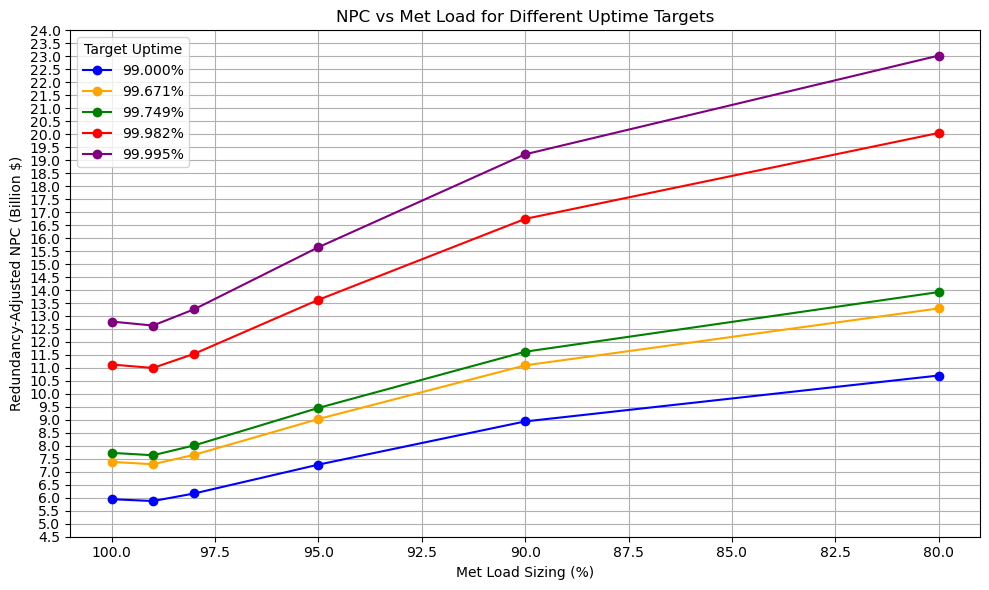


=== Redundancy Table for 99.00000% Reliability Target ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.00000%),Max Total NPC ($),Redundancy-Adjusted NPC ($) @ 99.00000%
0,80,65.707763,64.837,4.40616,2.430101e+09,1.070741e+10
1,90,79.212329,78.162,3.02668,2.953739e+09,8.940024e+09
2,95,88.698630,87.523,2.21269,3.288283e+09,7.275950e+09
3,98,94.452055,93.200,1.71309,3.599691e+09,6.166595e+09
4,99,96.495434,95.216,1.51490,3.877509e+09,5.874039e+09
5,100,99.257991,97.942,1.18584,5.013559e+09,5.945279e+09



=== Redundancy Table for 99.67100% Reliability Target ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.67100%),Max Total NPC ($),Redundancy-Adjusted NPC ($) @ 99.67100%
0,80,65.707763,64.837,5.46982,2.430101e+09,1.329221e+10
1,90,79.212329,78.162,3.75733,2.953739e+09,1.109817e+10
2,95,88.698630,87.523,2.74683,3.288283e+09,9.032353e+09
3,98,94.452055,93.200,2.12663,3.599691e+09,7.655211e+09
4,99,96.495434,95.216,1.88060,3.877509e+09,7.292044e+09
5,100,99.257991,97.942,1.47210,5.013559e+09,7.380461e+09



=== Redundancy Table for 99.74900% Reliability Target ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.74900%),Max Total NPC ($),Redundancy-Adjusted NPC ($) @ 99.74900%
0,80,65.707763,64.837,5.72873,2.430101e+09,1.392139e+10
1,90,79.212329,78.162,3.93518,2.953739e+09,1.162350e+10
2,95,88.698630,87.523,2.87685,3.288283e+09,9.459896e+09
3,98,94.452055,93.200,2.22730,3.599691e+09,8.017592e+09
4,99,96.495434,95.216,1.96961,3.877509e+09,7.637181e+09
5,100,99.257991,97.942,1.54178,5.013559e+09,7.729805e+09



=== Redundancy Table for 99.98200% Reliability Target ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.98200%),Max Total NPC ($),Redundancy-Adjusted NPC ($) @ 99.98200%
0,80,65.707763,64.837,8.24994,2.430101e+09,2.004819e+10
1,90,79.212329,78.162,5.66704,2.953739e+09,1.673896e+10
2,95,88.698630,87.523,4.14295,3.288283e+09,1.362319e+10
3,98,94.452055,93.200,3.20752,3.599691e+09,1.154608e+10
4,99,96.495434,95.216,2.83644,3.877509e+09,1.099832e+10
5,100,99.257991,97.942,2.22031,5.013559e+09,1.113166e+10



=== Redundancy Table for 99.99500% Reliability Target ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.99500%),Max Total NPC ($),Redundancy-Adjusted NPC ($) @ 99.99500%
0,80,65.707763,64.837,9.47552,2.430101e+09,2.302647e+10
1,90,79.212329,78.162,6.50891,2.953739e+09,1.922562e+10
2,95,88.698630,87.523,4.75841,3.288283e+09,1.564700e+10
3,98,94.452055,93.200,3.68402,3.599691e+09,1.326133e+10
4,99,96.495434,95.216,3.25780,3.877509e+09,1.263215e+10
5,100,99.257991,97.942,2.55015,5.013559e+09,1.278533e+10


In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# === Folder configuration ===
folders = {
    100: r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc",
    99:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment",
    98:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_98metLoadCostCurtailment",
    95:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_95metLoadCostCurtailment",
    90:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_90metLoadCostCurtailment",
    80:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_80metLoadCostCurtailment",
}
years = list(range(1980, 2025))
adjustment_factor = 0.99 * 0.99671
reliability_targets = [0.99, 0.99671, 0.99749, 0.99982, 0.99995]

# === Redundancy calculator ===
def compute_Ns_min(R_s, required_uptime):
    if R_s >= required_uptime:
        return 0.0
    Ns = np.log(1 - required_uptime) / np.log(1 - R_s)
    return np.ceil(Ns * 1e5) / 1e5

# === Data collection
raw_min_uptime = {}
adjusted_min_uptime = {}
npc_raw = {}
redundancy_results = {target: [] for target in reliability_targets}

for met, folder_path in folders.items():
    uptimes = []
    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        if not os.path.exists(file_path):
            continue
        try:
            df = pd.read_csv(file_path)
            unmet_hours = (df['Unmet (kW)'] > 0.00000001).sum()
            uptime = (1 - (unmet_hours / 8760)) * 100
            uptimes.append(uptime)
        except Exception:
            continue

    if uptimes:
        raw = np.min(uptimes)
        adjusted = raw * adjustment_factor
        raw_min_uptime[met] = raw
        adjusted_min_uptime[met] = adjusted

        # Read NPC
        cost_file = os.path.join(folder_path, "capacity_and_costs_by_year.csv")
        if os.path.exists(cost_file):
            try:
                df_cost = pd.read_csv(cost_file)
                npc = df_cost["Total_NPC"].max()
                npc_raw[met] = npc
                for target in reliability_targets:
                    R_s = adjusted / 100
                    Ns = compute_Ns_min(R_s, target)
                    npc_adj = npc * Ns
                    redundancy_results[target].append((met, raw, adjusted, Ns, npc, npc_adj))
            except Exception:
                continue

# === Plotting
colors = ['blue', 'orange', 'green', 'red', 'purple']
plt.figure(figsize=(10, 6))
for i, target in enumerate(reliability_targets):
    met_vals = [r[0] for r in redundancy_results[target]]
    npc_vals = [r[5] / 1e9 for r in redundancy_results[target]]
    plt.plot(met_vals, npc_vals, marker='o', label=f"{target*100:.3f}%", color=colors[i])

plt.xlabel("Met Load Sizing (%)")
plt.ylabel("Redundancy-Adjusted NPC (Billion $)")
#plt.yticks(np.arange(0, plt.ylim()[1]+0.5, 0.5))
plt.yticks(np.arange(4.5, 24.5, 0.5)); plt.ylim(4.5, 24)
plt.title("NPC vs Met Load for Different Uptime Targets")
plt.grid(True)
plt.legend(title="Target Uptime")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

# === Tabular outputs for all targets
def print_redundancy_table_for_target(target):
    df = pd.DataFrame(redundancy_results[target], columns=[
        "Met Load (%)", "Raw Min Uptime (%)", "Adjusted Min Uptime (%)",
        f"Required Ns (to reach {target*100:.5f}%)", "Max Total NPC ($)", f"Redundancy-Adjusted NPC ($) @ {target*100:.5f}%"
    ])
    df["Raw Min Uptime (%)"] = df["Raw Min Uptime (%)"].round(6)
    df["Adjusted Min Uptime (%)"] = df["Adjusted Min Uptime (%)"].round(3)
    df[f"Required Ns (to reach {target*100:.5f}%)"] = df[f"Required Ns (to reach {target*100:.5f}%)"].apply(lambda x: f"{x:.5f}")
    df["Max Total NPC ($)"] = df["Max Total NPC ($)"].map('{:.6e}'.format)
    df[f"Redundancy-Adjusted NPC ($) @ {target*100:.5f}%"] = df[f"Redundancy-Adjusted NPC ($) @ {target*100:.5f}%"].map('{:.6e}'.format)
    df.sort_values("Met Load (%)", inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"\n=== Redundancy Table for {target*100:.5f}% Reliability Target ===")
    display(df)
    return df

# Print and optionally export all tables
redundancy_tables = {}
for target in reliability_targets:
    redundancy_tables[target] = print_redundancy_table_for_target(target)


# Henderson Nevada

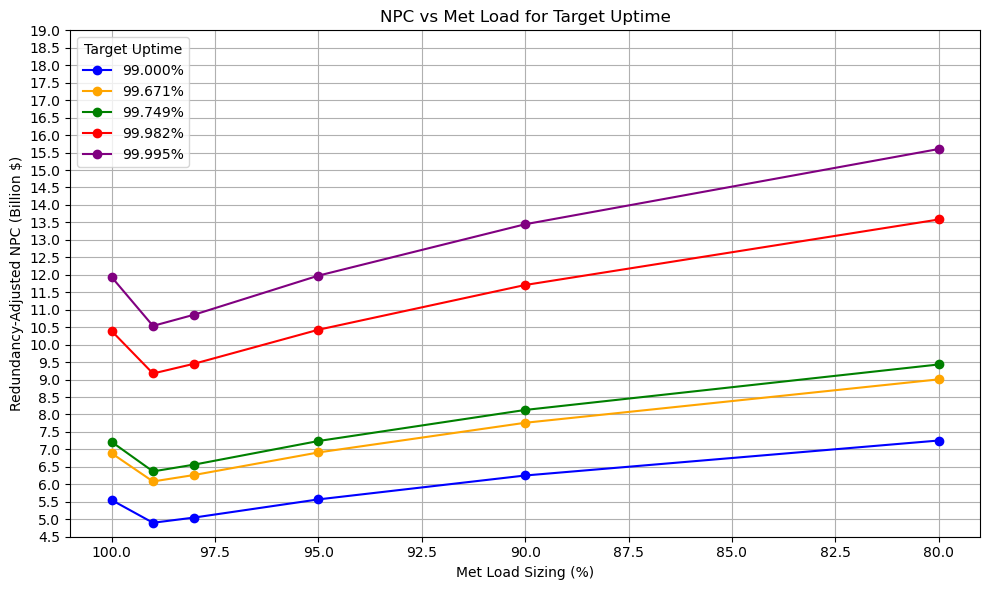


=== Reliability Target: 99.000% ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.000%),Max Total NPC ($),Redundancy-Adjusted NPC ($)
0,80,76.090613,75.082,3.31409,2.189041e+09,7.254679e+09
1,90,87.237834,86.081,2.33536,2.677560e+09,6.253066e+09
2,95,92.818636,91.588,1.86028,2.993576e+09,5.568890e+09
3,98,96.740587,95.458,1.48947,3.390174e+09,5.049562e+09
4,99,98.038803,96.739,1.34530,3.641982e+09,4.899558e+09
5,100,99.639647,98.319,1.12717,4.923666e+09,5.549809e+09



=== Reliability Target: 99.671% ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.671%),Max Total NPC ($),Redundancy-Adjusted NPC ($)
0,80,76.090613,75.082,4.11412,2.189041e+09,9.005977e+09
1,90,87.237834,86.081,2.89912,2.677560e+09,7.762567e+09
2,95,92.818636,91.588,2.30936,2.993576e+09,6.913246e+09
3,98,96.740587,95.458,1.84903,3.390174e+09,6.268533e+09
4,99,98.038803,96.739,1.67006,3.641982e+09,6.082328e+09
5,100,99.639647,98.319,1.39927,4.923666e+09,6.889538e+09



=== Reliability Target: 99.749% ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.749%),Max Total NPC ($),Redundancy-Adjusted NPC ($)
0,80,76.090613,75.082,4.30886,2.189041e+09,9.432271e+09
1,90,87.237834,86.081,3.03634,2.677560e+09,8.129981e+09
2,95,92.818636,91.588,2.41867,2.993576e+09,7.240473e+09
3,98,96.740587,95.458,1.93656,3.390174e+09,6.565275e+09
4,99,98.038803,96.739,1.74911,3.641982e+09,6.370227e+09
5,100,99.639647,98.319,1.46551,4.923666e+09,7.215682e+09



=== Reliability Target: 99.982% ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.982%),Max Total NPC ($),Redundancy-Adjusted NPC ($)
0,80,76.090613,75.082,6.20518,2.189041e+09,1.358339e+10
1,90,87.237834,86.081,4.37263,2.677560e+09,1.170798e+10
2,95,92.818636,91.588,3.48312,2.993576e+09,1.042699e+10
3,98,96.740587,95.458,2.78883,3.390174e+09,9.454618e+09
4,99,98.038803,96.739,2.51889,3.641982e+09,9.173752e+09
5,100,99.639647,98.319,2.11047,4.923666e+09,1.039125e+10



=== Reliability Target: 99.995% ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.995%),Max Total NPC ($),Redundancy-Adjusted NPC ($)
0,80,76.090613,75.082,7.12700,2.189041e+09,1.560129e+10
1,90,87.237834,86.081,5.02222,2.677560e+09,1.344729e+10
2,95,92.818636,91.588,4.00056,2.993576e+09,1.197598e+10
3,98,96.740587,95.458,3.20313,3.390174e+09,1.085917e+10
4,99,98.038803,96.739,2.89308,3.641982e+09,1.053655e+10
5,100,99.639647,98.319,2.42400,4.923666e+09,1.193497e+10


In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# === Folder configuration ===
folders = {
    100: r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dcNevada2023",
    99:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metloadNevada2023",
    98:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_98metloadNevada2023", 
    95:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_95metloadNevada2023",
    90:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_90metloadNevada2023",
    80:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_80metloadNevada2023", 
}
years = list(range(1980, 2025))
combined_factor = 0.99 * 0.99671
reliability_targets = [0.99, 0.99671, 0.99749, 0.99982, 0.99995]

# === Interpolation setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]
extension_factors = training_times / baseline_time
power_missing_fraction = (250 - power_watts) / 250
interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

def get_training_extension(power_percent):
    power_percent = np.clip(power_percent, 0, 100)
    missing_fraction = 1 - (power_percent / 100)
    return interpolator(missing_fraction)

def compute_Ns_min(R_s, required_uptime):
    if R_s >= required_uptime:
        return 0.0
    Ns = np.log(1 - required_uptime) / np.log(1 - R_s)
    return np.ceil(Ns * 1e5) / 1e5

# === Collect worst-case uptimes and max NPCs
results = []
npc_data = {}

for met, folder_path in folders.items():
    yearly_uptimes = []
    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        try:
            df = pd.read_csv(file_path)
            unmet_rows = df[df['Unmet (kW)'] > 0].copy()
            if unmet_rows.empty:
                yearly_uptimes.append(100.0)
                continue
            unmet_rows['Unmet (%)'] = (unmet_rows['Unmet (kW)'] / unmet_rows['Load (kW)']) * 100
            unmet_rows['Power Available (%)'] = 100 - unmet_rows['Unmet (%)']
            unmet_rows['Training Time Extension (×)'] = unmet_rows['Power Available (%)'].apply(
                lambda p: 2.0 if p < (100 / 250 * 100) else get_training_extension(p)
            )
            unmet_rows['Extra Training Hours'] = unmet_rows['Training Time Extension (×)'] - 1
            total_extra = unmet_rows['Extra Training Hours'].sum()
            uptime = (1 - total_extra / 8760) * 100
            yearly_uptimes.append(uptime)
        except Exception as e:
            print(f"Error in {folder_path}, year {year}: {e}")
            yearly_uptimes.append(None)

    valid_uptimes = [u for u in yearly_uptimes if u is not None]
    if valid_uptimes:
        raw = min(valid_uptimes)
        adj = raw * combined_factor
        results.append((met, raw, adj))
        try:
            npc_file = os.path.join(folder_path, "capacity_and_costs_by_year.csv")
            df_npc = pd.read_csv(npc_file)
            npc_data[met] = df_npc["Total_NPC"].max()
        except Exception as e:
            print(f"Could not read NPC in {folder_path}: {e}")
            npc_data[met] = None

# === Redundancy-adjusted NPC calculations
redundancy_results = {target: [] for target in reliability_targets}
plot_data = {target: [] for target in reliability_targets}
met_levels = sorted(folders.keys())

for target in reliability_targets:
    for met in met_levels:
        row = [r for r in results if r[0] == met][0]
        raw_uptime, adj_uptime = row[1], row[2]
        npc = npc_data.get(met, None)
        R_s = adj_uptime / 100
        Ns = compute_Ns_min(R_s, target)
        npc_adj = npc * Ns if npc is not None else None
        redundancy_results[target].append((met, raw_uptime, adj_uptime, Ns, npc, npc_adj))
        plot_data[target].append(npc_adj / 1e9 if npc_adj is not None else None)

# === Plot NPCs
colors = ['blue', 'orange', 'green', 'red', 'purple']
plt.figure(figsize=(10, 6))
for i, target in enumerate(reliability_targets):
    label = f"{target*100:.3f}%"
    plt.plot(met_levels, plot_data[target], marker='o', label=label, color=colors[i])
plt.xlabel("Met Load Sizing (%)")
plt.ylabel("Redundancy-Adjusted NPC (Billion $)")
plt.yticks(np.arange(4.5, 19.5, 0.5)); plt.ylim(4.5, 19)
plt.title("NPC vs Met Load for Target Uptime")
plt.grid(True)
plt.legend(title="Target Uptime")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

# === Print redundancy tables
redundancy_tables = {}

def print_redundancy_table_for_target(target):
    table = pd.DataFrame(redundancy_results[target], columns=[
        "Met Load (%)",
        "Raw Min Uptime (%)",
        "Adjusted Min Uptime (%)",
        f"Required Ns (to reach {target*100:.3f}%)",
        "Max Total NPC ($)",
        "Redundancy-Adjusted NPC ($)"
    ])
    table["Raw Min Uptime (%)"] = table["Raw Min Uptime (%)"].round(6)
    table["Adjusted Min Uptime (%)"] = table["Adjusted Min Uptime (%)"].round(3)
    table[f"Required Ns (to reach {target*100:.3f}%)"] = table[f"Required Ns (to reach {target*100:.3f}%)"].apply(lambda x: f"{x:.5f}")
    table["Max Total NPC ($)"] = table["Max Total NPC ($)"].map('{:.6e}'.format)
    table["Redundancy-Adjusted NPC ($)"] = table["Redundancy-Adjusted NPC ($)"].map('{:.6e}'.format)
    table.sort_values("Met Load (%)", inplace=True)
    table.reset_index(drop=True, inplace=True)
    return table

for target in reliability_targets:
    print(f"\n=== Reliability Target: {target*100:.3f}% ===")
    redundancy_tables[target] = print_redundancy_table_for_target(target)
    display(redundancy_tables[target])


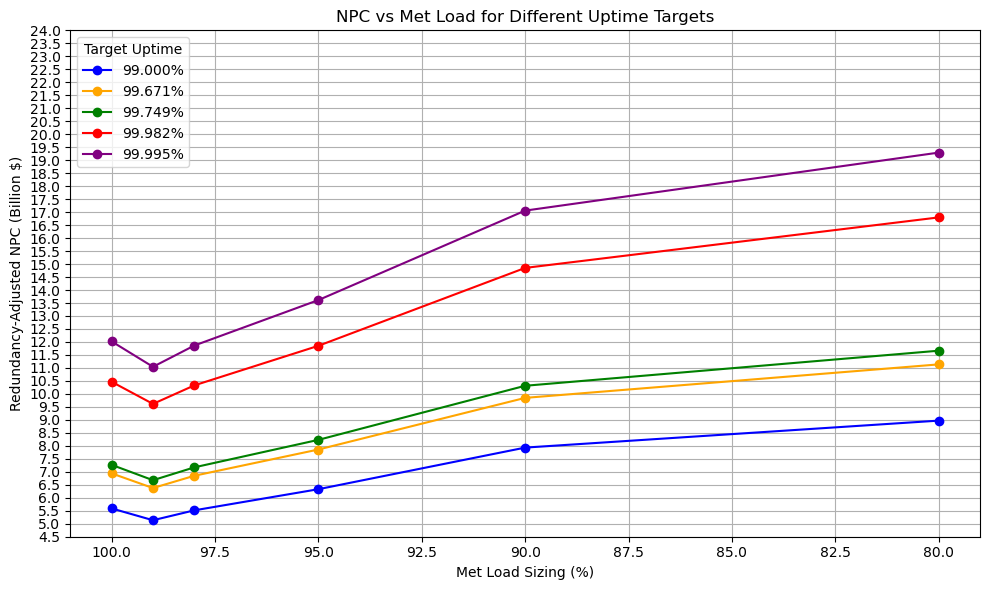


=== Redundancy Table for 99.00000% Reliability Target ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.00000%),Max Total NPC ($),Redundancy-Adjusted NPC ($) @ 99.00000%
0,80,68.401826,67.495,4.09795,2.189041e+09,8.970580e+09
1,90,79.931507,78.872,2.96236,2.677560e+09,7.931895e+09
2,95,89.863014,88.672,2.11454,2.993576e+09,6.330037e+09
3,98,95.365297,94.101,1.62705,3.390174e+09,5.515982e+09
4,99,97.477169,96.185,1.40995,3.641982e+09,5.135012e+09
5,100,99.589041,98.269,1.13531,4.923666e+09,5.589887e+09



=== Redundancy Table for 99.67100% Reliability Target ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.67100%),Max Total NPC ($),Redundancy-Adjusted NPC ($) @ 99.67100%
0,80,68.401826,67.495,5.08720,2.189041e+09,1.113609e+10
1,90,79.931507,78.872,3.67748,2.677560e+09,9.846672e+09
2,95,89.863014,88.672,2.62499,2.993576e+09,7.858108e+09
3,98,95.365297,94.101,2.01982,3.390174e+09,6.847540e+09
4,99,97.477169,96.185,1.75031,3.641982e+09,6.374597e+09
5,100,99.589041,98.269,1.40937,4.923666e+09,6.939267e+09



=== Redundancy Table for 99.74900% Reliability Target ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.74900%),Max Total NPC ($),Redundancy-Adjusted NPC ($) @ 99.74900%
0,80,68.401826,67.495,5.32800,2.189041e+09,1.166321e+10
1,90,79.931507,78.872,3.85155,2.677560e+09,1.031275e+10
2,95,89.863014,88.672,2.74924,2.993576e+09,8.230060e+09
3,98,95.365297,94.101,2.11543,3.390174e+09,7.171675e+09
4,99,97.477169,96.185,1.83316,3.641982e+09,6.676336e+09
5,100,99.589041,98.269,1.47608,4.923666e+09,7.267725e+09



=== Redundancy Table for 99.98200% Reliability Target ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.98200%),Max Total NPC ($),Redundancy-Adjusted NPC ($) @ 99.98200%
0,80,68.401826,67.495,7.67284,2.189041e+09,1.679616e+10
1,90,79.931507,78.872,5.54661,2.677560e+09,1.485138e+10
2,95,89.863014,88.672,3.95918,2.993576e+09,1.185211e+10
3,98,95.365297,94.101,3.04642,3.390174e+09,1.032789e+10
4,99,97.477169,96.185,2.63994,3.641982e+09,9.614614e+09
5,100,99.589041,98.269,2.12570,4.923666e+09,1.046624e+10



=== Redundancy Table for 99.99500% Reliability Target ===


,Met Load (%),Raw Min Uptime (%),Adjusted Min Uptime (%),Required Ns (to reach 99.99500%),Max Total NPC ($),Redundancy-Adjusted NPC ($) @ 99.99500%
0,80,68.401826,67.495,8.81269,2.189041e+09,1.929134e+10
1,90,79.931507,78.872,6.37059,2.677560e+09,1.705763e+10
2,95,89.863014,88.672,4.54734,2.993576e+09,1.361281e+10
3,98,95.365297,94.101,3.49899,3.390174e+09,1.186218e+10
4,99,97.477169,96.185,3.03211,3.641982e+09,1.104289e+10
5,100,99.589041,98.269,2.44149,4.923666e+09,1.202108e+10


In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# === Folder configuration ===
folders = {
    100: r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dcNevada2023",
    99:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metloadNevada2023",
    98:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_98metloadNevada2023", 
    95:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_95metloadNevada2023",
    90:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_90metloadNevada2023",
    80:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_80metloadNevada2023",
}
years = list(range(1980, 2025))
adjustment_factor = 0.99 * 0.99671
reliability_targets = [0.99, 0.99671, 0.99749, 0.99982, 0.99995]

# === Redundancy calculator ===
def compute_Ns_min(R_s, required_uptime):
    if R_s >= required_uptime:
        return 0.0
    Ns = np.log(1 - required_uptime) / np.log(1 - R_s)
    return np.ceil(Ns * 1e5) / 1e5

# === Data collection
raw_min_uptime = {}
adjusted_min_uptime = {}
npc_raw = {}
redundancy_results = {target: [] for target in reliability_targets}

for met, folder_path in folders.items():
    uptimes = []
    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        if not os.path.exists(file_path):
            continue
        try:
            df = pd.read_csv(file_path)
            unmet_hours = (df['Unmet (kW)'] > 0.00000001).sum()
            uptime = (1 - (unmet_hours / 8760)) * 100
            uptimes.append(uptime)
        except Exception:
            continue

    if uptimes:
        raw = np.min(uptimes)
        adjusted = raw * adjustment_factor
        raw_min_uptime[met] = raw
        adjusted_min_uptime[met] = adjusted

        # Read NPC
        cost_file = os.path.join(folder_path, "capacity_and_costs_by_year.csv")
        if os.path.exists(cost_file):
            try:
                df_cost = pd.read_csv(cost_file)
                npc = df_cost["Total_NPC"].max()
                npc_raw[met] = npc
                for target in reliability_targets:
                    R_s = adjusted / 100
                    Ns = compute_Ns_min(R_s, target)
                    npc_adj = npc * Ns
                    redundancy_results[target].append((met, raw, adjusted, Ns, npc, npc_adj))
            except Exception:
                continue

# === Plotting
colors = ['blue', 'orange', 'green', 'red', 'purple']
plt.figure(figsize=(10, 6))
for i, target in enumerate(reliability_targets):
    met_vals = [r[0] for r in redundancy_results[target]]
    npc_vals = [r[5] / 1e9 for r in redundancy_results[target]]
    plt.plot(met_vals, npc_vals, marker='o', label=f"{target*100:.3f}%", color=colors[i])

plt.xlabel("Met Load Sizing (%)")
plt.ylabel("Redundancy-Adjusted NPC (Billion $)")
#plt.yticks(np.arange(0, plt.ylim()[1]+0.5, 0.5))
plt.yticks(np.arange(4.5, 24.5, 0.5)); plt.ylim(4.5, 24)
plt.title("NPC vs Met Load for Different Uptime Targets")
plt.grid(True)
plt.legend(title="Target Uptime")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

# === Tabular outputs for all targets
def print_redundancy_table_for_target(target):
    df = pd.DataFrame(redundancy_results[target], columns=[
        "Met Load (%)", "Raw Min Uptime (%)", "Adjusted Min Uptime (%)",
        f"Required Ns (to reach {target*100:.5f}%)", "Max Total NPC ($)", f"Redundancy-Adjusted NPC ($) @ {target*100:.5f}%"
    ])
    df["Raw Min Uptime (%)"] = df["Raw Min Uptime (%)"].round(6)
    df["Adjusted Min Uptime (%)"] = df["Adjusted Min Uptime (%)"].round(3)
    df[f"Required Ns (to reach {target*100:.5f}%)"] = df[f"Required Ns (to reach {target*100:.5f}%)"].apply(lambda x: f"{x:.5f}")
    df["Max Total NPC ($)"] = df["Max Total NPC ($)"].map('{:.6e}'.format)
    df[f"Redundancy-Adjusted NPC ($) @ {target*100:.5f}%"] = df[f"Redundancy-Adjusted NPC ($) @ {target*100:.5f}%"].map('{:.6e}'.format)
    df.sort_values("Met Load (%)", inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"\n=== Redundancy Table for {target*100:.5f}% Reliability Target ===")
    display(df)
    return df

# Print and optionally export all tables
redundancy_tables = {}
for target in reliability_targets:
    redundancy_tables[target] = print_redundancy_table_for_target(target)
